In [1]:
import svgwrite

In [19]:
dwg = svgwrite.Drawing(height='500px', width='100px') 

In [20]:
dwg.add(dwg.rect((10, 10), (300, 200),
    stroke=svgwrite.rgb(10, 10, 16, '%'),
    fill='red')
)
dwg

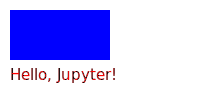

In [21]:
import svgwrite

def create_svg():
    # Create a new SVG drawing
    dwg = svgwrite.Drawing('test.svg', size=('200px', '100px'), profile='tiny')
    # Add a rectangle
    dwg.add(dwg.rect((10, 10), (100, 50), fill='blue'))
    # Add a text element
    dwg.add(dwg.text('Hello, Jupyter!', insert=(10, 80), fill='red', font_size='15px'))
    return dwg

# The notebook automatically displays the returned object
create_svg()


In [23]:
import svgwrite
import math

def create_pie_slice(filename, center_x, center_y, radius, start_angle_deg, end_angle_deg, fill_color):
    """
    Creates an SVG file with a single pie slice.

    Angles are in degrees, starting from the positive X-axis (right) and moving counter-clockwise.
    """
    dwg = svgwrite.Drawing(filename, profile='tiny', size=("200px", "200px"))
    
    # Convert degrees to radians
    start_angle_rad = math.radians(start_angle_deg)
    end_angle_rad = math.radians(end_angle_deg)
    
    # Calculate start and end points
    start_x = center_x + radius * math.cos(start_angle_rad)
    start_y = center_y + radius * math.sin(start_angle_rad)
    end_x = center_x + radius * math.cos(end_angle_rad)
    end_y = center_y + radius * math.sin(end_angle_rad)
    
    # Determine if the arc is large (greater than 180 degrees)
    # The sweep flag (1) determines the direction of the arc
    # For simplicity, we calculate the angular difference
    angle_diff = (end_angle_deg - start_angle_deg) % 360
    large_arc_flag = 1 if angle_diff >= 180 else 0
    
    # The 'd' attribute string for the path:
    # M: Move to the center (start of the slice)
    # L: Line to the start point of the arc
    # A: Arc command (rx, ry, x-axis-rotation, large-arc-flag, sweep-flag, end-x, end-y)
    # Z: Close the path (draws a line back to the starting point, the center)
    path_data = "M {cx},{cy} L {sx},{sy} A {r},{r} 0 {large_arc_flag},1 {ex},{ey} Z".format(
        cx=center_x, cy=center_y, 
        sx=start_x, sy=start_y, 
        r=radius, 
        large_arc_flag=large_arc_flag, 
        ex=end_x, ey=end_y
    )
    
    # Create and add the path to the drawing
    dwg.add(dwg.path(d=path_data, fill=fill_color, stroke="black", stroke_width=1))
    
    dwg.save()

# Example usage: create a 45-degree red slice starting from 0 degrees (right side)
create_pie_slice("pieslice_example.svg", 100, 100, 80, 0, 45, "red")

# Example usage: create a 90-degree blue slice starting from 90 degrees (top)
create_pie_slice("pieslice_example2.svg", 100, 100, 80, 90, 180, "blue")


# Standard Dimensions

## Main Bars
90 degree + 12*dia_bars
180 degree + max(4*dia_bars, 2.5*inch)

## Stirrup and Tie Bars
A. 90 degree + 6*dia_bars > 3*inch (for #3, #4, and #5 bars)
B. 90 degree + 12*dia_bars (for #6, #7, and #8 bars)
C. 135 degree + 6*dia_bars > 3*inch (for #3, #4, #5, #6, #7, and #8 bars)
D. 180 degree + max(4*dia_bars, 2.5*inch) (for #3, #4, #5, #6, #7, and #8 bars)

In [ ]:
from enum import Enum

class BarFunction(Enum):
    MAIN = "Tension bars"
    STIRRUP = "Stirrup or Tie"


class HookedBar:
    def __init__(self, diameter:int, hook_angle_deg:int, bar_function:BarFunction = BarFunction.STIRRUP):
        self.diameter = diameter
        self.hook_angle_deg = hook_angle_deg
        self.bar_function = bar_function
    
    @property
    def hook_length(self):
        if self.bar_function == BarFunction.MAIN:
            return self.cal_main_hook_length()
        elif self.bar_function == BarFunction.STIRRUP:
            return self.cal_stirrup_hook_length()
        else:
            raise ValueError("Unsupported bar function")
    
    def cal_main_hook_length(self):
        """Calculate main bar hook length based on diameter and angle."""
        if self.hook_angle_deg == 90:
            return max(12 * self.diameter, 6)  # in inches
        elif self.hook_angle_deg == 180:
            return max(4 * self.diameter, 2.5) # in inches
        else:
            raise ValueError("Unsupported hook angle for main bars")
        
    def cal_stirrup_hook_length(self):
        """Calculate stirrup/tie bar hook length based on diameter and angle."""
        if self.hook_angle_deg == 90:
            if self.diameter <= 5:
                return max(6 * self.diameter, 3)  # in inches
            else:
                return 12 * self.diameter  # in inches
        elif self.hook_angle_deg == 135:
            return max(6 * self.diameter, 3)  # in inches
        elif self.hook_angle_deg == 180:
            return max(4 * self.diameter, 2.5) # in inches
        else:
            raise ValueError("Unsupported hook angle for stirrup/tie bars")
        
    def cal_inside_bend_radius(self):
        """Calculate inside bend radius based on diameter and bar function."""
        if self.bar_function == BarFunction.MAIN:
            if self.diameter <= 8:
                return 3 * self.diameter  # in inches
            elif self.diameter > 8 and self.diameter <= 11:
                return 4 * self.diameter  # in inches
            elif self.diameter > 11 and self.diameter <= 18:
                return 5 * self.diameter  # in inches
        
        elif self.bar_function == BarFunction.STIRRUP:
            return 4 * self.diameter  # in inches
        else:
            raise ValueError("Unsupported bar function")